# Logistic Regression Classifier

Logistic Regression is used for Classification. Unlike linear regression, Logistic regression predicts probability for the input belongs to specific class.  

1. Used for Binary Classification.
2. It uses sigmoid function, which gives probability (i.e. between 0 to 1) for the class, to which input belongs to. 

### Types of Logistic Regression  

1. Binomial Logistic Regression:  
   It is used for Binary Classification, in which the dependent variable has two possible categories  

2. Multinomial Logistic Regression:
   It is used for Multi Classification task, in which the dependent variable have more than two categories/classes that are not ordered. For e.g. cat, dog, cow etc.

3. Ordinal Logistic Regression:
   It is used for Multi Classification task, in which the dependent variable have more then two categories with natural order. For e.g. LOW, MEDIUM, HIGH,

### Use of Sigmoid function to convert raw output from model into Probability

1. The sigmoid function takes the output of the model and map it into the range from 0 to 1. Forming a "S"-shaped curve.  
2. In logistic regression, we have to set the threshold for predicting the class labels/Categories.  
3. The threshold is usually set to 0.5.  
4. If the probability of sigmoid is equals or greater than 0.5 then the input is classified as Category 1.
5. If the probability is less than 0.5 then the input is classified as Category 2.  


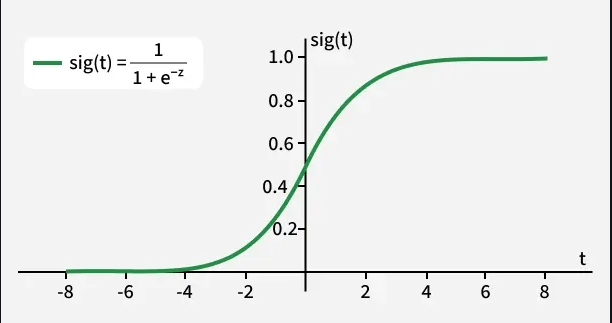

### How Logistic regression works?  

Logistic regression transform the continuous output values of the Linear regression model into probability using a sigmoid function.  

Suppose the input features are represented as matrix;  

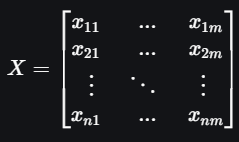

and the dependent variable hva binary values 

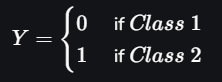

Then the output of the regression model is represented as   

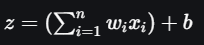

Where x<sub>i</sub> is the ith observation of X, w<sub>i</sub> = [w<sub>1</sub>, w<sub>2</sub>, ..., w<sub>m</sub>]  

The above equations simplified as  

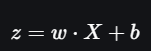

Hence the output from the linear regression model is continuous.

For Predicting categories/classes we use sigmoid function to transform the 'z' output of regression model into probability (0 to 1)

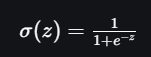

As shown above the sigmoid function converts the continuous variable data into the probability i.e between 0 and 1. 

σ(z)   tends towards 1 as z → ∞
   
σ(z)    tends towards 0 as z → −∞
   
σ(z)    is always bounded between 0 and 1

where the probability of being a class can be measured as:

P(y=1) = σ(z)  
P(y=0) = 1−σ(z)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix


## Binomial Logistic Regression

In binomial Logistic Regression, target variable have two possible values i.e. "0" or "1"

In [2]:
df = pd.read_csv('Breast cancer dataset/Breast_cancer_data.csv')

In [3]:
df

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0
1,20.57,17.77,132.90,1326.0,0.08474,0
2,19.69,21.25,130.00,1203.0,0.10960,0
3,11.42,20.38,77.58,386.1,0.14250,0
4,20.29,14.34,135.10,1297.0,0.10030,0
...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0
565,20.13,28.25,131.20,1261.0,0.09780,0
566,16.60,28.08,108.30,858.1,0.08455,0
567,20.60,29.33,140.10,1265.0,0.11780,0


### Demonstration that there is no correlation between the input samples for Classification Problem

In [4]:
df.corr()

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,diagnosis
mean_radius,1.000000,0.323782,0.997855,0.987357,0.170581,-0.730029
mean_texture,0.323782,1.000000,0.329533,0.321086,-0.023389,-0.415185
mean_perimeter,0.997855,0.329533,1.000000,0.986507,0.207278,-0.742636
mean_area,0.987357,0.321086,0.986507,1.000000,0.177028,-0.708984
mean_smoothness,0.170581,-0.023389,0.207278,0.177028,1.000000,-0.358560
diagnosis,-0.730029,-0.415185,-0.742636,-0.708984,-0.358560,1.000000


<Axes: >

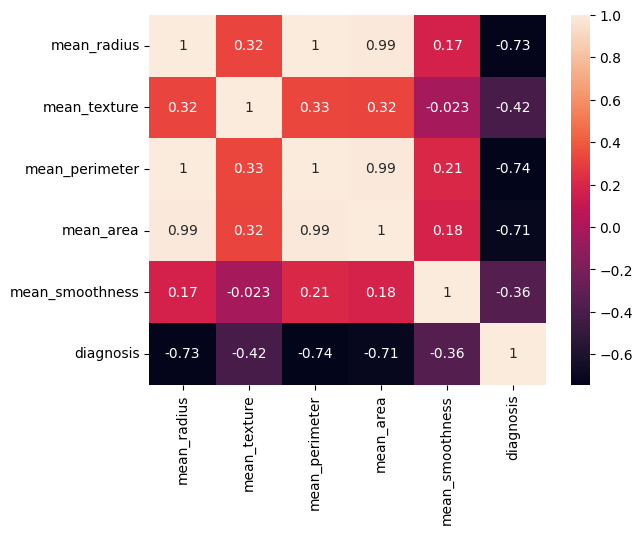

In [5]:
sns.heatmap(df.corr(), annot=True)

#### Seperating input and output features

In [6]:
X = df.drop('diagnosis', axis=1)

Y = df['diagnosis']

In [7]:
X

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness
0,17.99,10.38,122.80,1001.0,0.11840
1,20.57,17.77,132.90,1326.0,0.08474
2,19.69,21.25,130.00,1203.0,0.10960
3,11.42,20.38,77.58,386.1,0.14250
4,20.29,14.34,135.10,1297.0,0.10030
...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100
565,20.13,28.25,131.20,1261.0,0.09780
566,16.60,28.08,108.30,858.1,0.08455
567,20.60,29.33,140.10,1265.0,0.11780


In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=123)

In [9]:
X_train

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness
559,11.51,23.93,74.52,403.5,0.09261
295,13.77,13.27,88.06,582.7,0.09198
264,17.19,22.07,111.60,928.3,0.09726
125,13.85,17.21,88.44,588.7,0.08785
280,19.16,26.60,126.20,1138.0,0.10200
...,...,...,...,...,...
98,11.60,12.84,74.34,412.6,0.08983
322,12.86,13.32,82.82,504.8,0.11340
382,12.05,22.72,78.75,447.8,0.06935
365,20.44,21.78,133.80,1293.0,0.09150


In [10]:
blr = LogisticRegression(max_iter=10000)

In [11]:
blr.fit(X_train, y_train)

LogisticRegression(max_iter=10000)

#### Evaluating model Preformance  

1. Accuracy:  

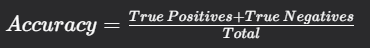

2. Precision:  

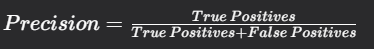

3. Recall:  

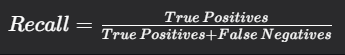

4. F1-Score:  

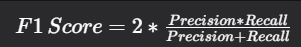

In [13]:
conf_mat = confusion_matrix(y_test, blr.predict(X_test))

conf_mat

array([[ 56,  12],
       [  2, 101]], dtype=int64)

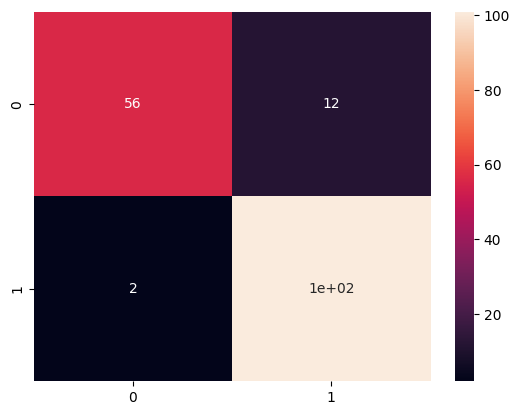

In [15]:
sns.heatmap(conf_mat, annot=True)

plt.show()

In [16]:
accuracy = accuracy_score(y_test, blr.predict(X_test)) * 100

print("Prediction accuracy: ", accuracy)

Prediction accuracy:  91.81286549707602


In [17]:
precision = precision_score(y_test, blr.predict(X_test)) 

print("precision: ", precision)

precision:  0.8938053097345132


In [34]:
recall = recall_score(y_test, blr.predict(X_test))

print("Recall: ", recall)

Recall:  0.9805825242718447
